# 1.1 - Data Loading and Preview

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('figures', exist_ok=True)

df = pd.read_csv('creditcard.csv')

print(f"Dataset dimensions: {df.shape}")
print("\nPreview of the first 5 rows of the dataset:")
df.head()

Dataset dimensions: (284807, 31)

Preview of the first 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 1.2 - Data Types and Missing Values Exploration

In [167]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing values per column ===")
print(df.isnull().sum())

print("\n=== Total number of missing values ===")
print(df.isnull().sum().sum())


=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Missing values per column ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dt

# 1.3 - Descriptive Statistics

In [168]:
print("=== Descriptive statistical summary ===")
print(df.describe())

print("\n=== Distribution of the target variable (Class) ===")
print(df['Class'].value_counts())
print("\nPercentage :")
print(df['Class'].value_counts(normalize=True) * 100)

=== Descriptive statistical summary ===
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
st

# 1.4 - Class Imbalance Visualization

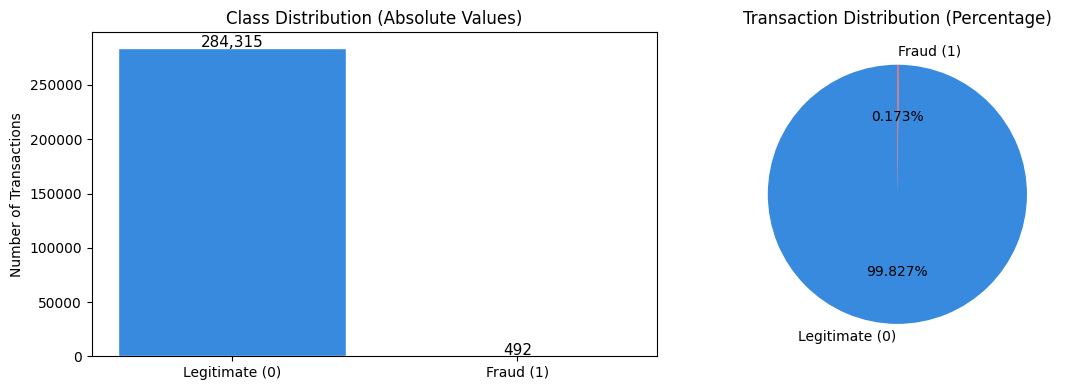

Class distribution plot successfully saved


In [169]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#378ADD', '#E24B4A']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Absolute Values)')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.3f%%', startangle=90)
axes[1].set_title('Transaction Distribution (Percentage)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution plot successfully saved")

# 1.5 - Time and Amount Distribution

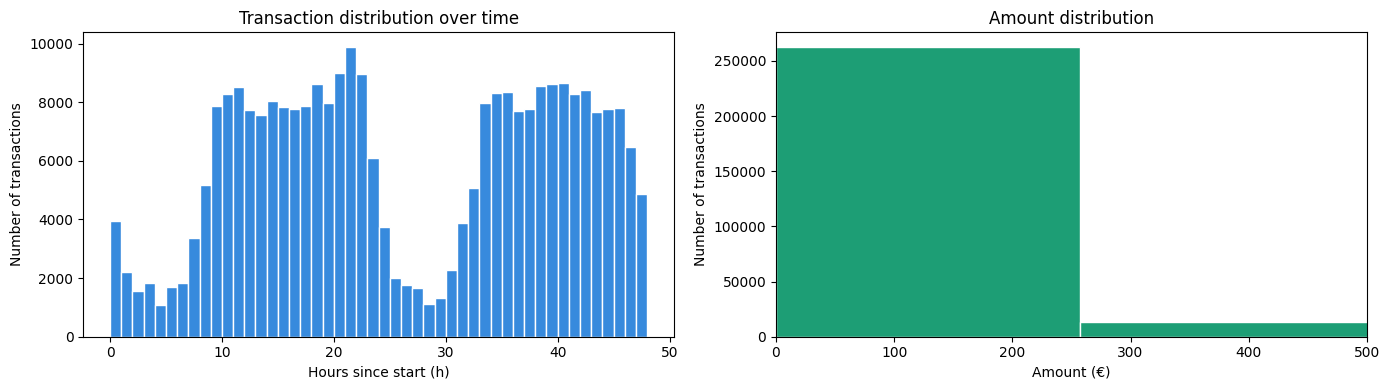

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Time'] / 3600, bins=48, color='#378ADD', edgecolor='white')
axes[0].set_title('Transaction distribution over time')
axes[0].set_xlabel('Hours since start (h)')
axes[0].set_ylabel('Number of transactions')

axes[1].hist(df['Amount'], bins=100, color='#1D9E75', edgecolor='white')
axes[1].set_title('Amount distribution')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Number of transactions')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig('figures/time_amount_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# 1.6 - Fraud vs Legitimate Transactions Amount Comparison

=== Amount statistics by class ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


/tmp/ipykernel_4475/2280457243.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axe.boxplot([legit['Amount'], fraud['Amount']],


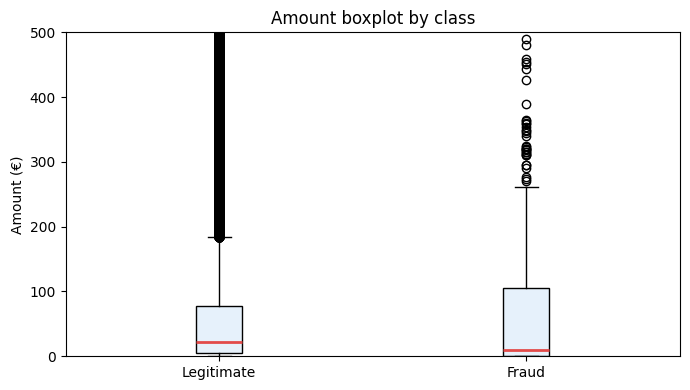

In [171]:
fig, axe = plt.subplots(1, 1, figsize=(7, 4))

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("=== Amount statistics by class ===")
print(df.groupby('Class')['Amount'].describe().round(2))

axe.boxplot([legit['Amount'], fraud['Amount']],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'),
                medianprops=dict(color='#E24B4A', linewidth=2))
axe.set_title('Amount boxplot by class')
axe.set_ylabel('Amount (€)')
axe.set_ylim(0, 500)

plt.tight_layout()
plt.savefig('figures/amount_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.1 - Verification and Removal of Duplicates

In [172]:
print("=== Cleaning: duplicates and empty rows ===")
print(f"Original shape: {df.shape}")

df_clean = df.dropna(how='all')
print(f"After removing empty rows   : {df_clean.shape}")
print(f"Empty rows removed          : {df.shape[0] - df_clean.shape[0]}")

nb_doublons = df_clean.duplicated().sum()
print(f"\nDuplicates detected         : {nb_doublons}")
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates   : {df_clean.shape}")
print(f"Total rows removed          : {df.shape[0] - df_clean.shape[0]}")

=== Cleaning: duplicates and empty rows ===
Original shape: (284807, 31)
After removing empty rows   : (284807, 31)
Empty rows removed          : 0

Duplicates detected         : 1081
After removing duplicates   : (283726, 31)
Total rows removed          : 1081


# 2.2 - Missing Values Confirmation

In [173]:
print("=== Missing values after cleaning ===")
missing = df_clean.isnull().sum()

if missing.sum() == 0:
    print("No missing values — clean dataset.")
else:
    print("Remaining missing values:")
    print(missing[missing > 0])

print(f"\nTotal missing values: {missing.sum()}")

=== Missing values after cleaning ===
No missing values — clean dataset.

Total missing values: 0


# 2.3 - Data Types Verification

In [174]:
print("=== Data types ===")
print(df_clean.dtypes)

print("\n=== Checking that Class is binary ===")
valeurs_class = df_clean['Class'].unique()
print("Unique values in Class:", valeurs_class)

if set(valeurs_class) == {0.0, 1.0}:
    print("Correct — Class contains only 0 and 1.")
else:
    print("Warning — unexpected values in Class:", valeurs_class)

print("\n=== Final Class distribution ===")
print(df_clean['Class'].value_counts())
print(df_clean['Class'].value_counts(normalize=True).mul(100).round(3))

=== Data types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Checking that Class is binary ===
Unique values in Class: [0 1]
Correct — Class contains only 0 and 1.

=== Final Class distribution ===
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.833
1     0.167
Name: proportion, dtype: float64


# 2.4 - Outlier Analysis on Amount

In [175]:
print("=== Outlier analysis on Amount ===")
Q1 = df_clean['Amount'].quantile(0.25)
Q3 = df_clean['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Amount'] < lower) | (df_clean['Amount'] > upper)]
print(f"Q1          : {Q1:.2f} €")
print(f"Q3          : {Q3:.2f} €")
print(f"IQR         : {IQR:.2f} €")
print(f"Lower bound : {lower:.2f} €")
print(f"Upper bound : {upper:.2f} €")
print(f"Nb outliers : {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

print("\n=== Outlier distribution by class ===")
print(outliers['Class'].value_counts())

=== Outlier analysis on Amount ===
Q1          : 5.60 €
Q3          : 77.51 €
IQR         : 71.91 €
Lower bound : -102.27 €
Upper bound : 185.38 €
Nb outliers : 31685 (11.17%)

=== Outlier distribution by class ===
Class
0    31598
1       87
Name: count, dtype: int64


# 2.5 - Feature Scaling (Time and Amount)

In [176]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_clean['Hour'] = (df_clean['Time'] // 3600) % 24
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train size : {X_train.shape}")
print(f"X_test size  : {X_test.shape}")
print(f"Fraud train  : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud test   : {y_test.sum()} ({y_test.mean()*100:.3f}%)")

scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

X_train size : (226980, 31)
X_test size  : (56746, 31)
Fraud train  : 378 (0.167%)
Fraud test   : 95 (0.167%)


# 2.6 - Exporting Clean Data

In [177]:
os.makedirs('data', exist_ok=True)

X_train.to_csv('data/X_train.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print("=== Fichiers exportés dans data/ ===")
print("  X_train.csv :", X_train.shape)
print("  X_test.csv  :", X_test.shape)
print("  y_train.csv :", y_train.shape)
print("  y_test.csv  :", y_test.shape)

=== Fichiers exportés dans data/ ===
  X_train.csv : (226980, 31)
  X_test.csv  : (56746, 31)
  y_train.csv : (226980,)
  y_test.csv  : (56746,)


# 2.7 - Data Cleaning Summary (For Report)

In [178]:
print("=" * 50)
print("CLEANING DECISIONS SUMMARY")
print("=" * 50)
print(f"Original dataset       : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicates removed     : {df.shape[0] - df_clean.shape[0]}")
print(f"Missing values         : 0 (no treatment needed)")
print(f"Columns removed        : none")
print(f"Amount outliers        : kept (relevant for fraud detection)")
print(f"Scaled columns         : Time, Amount (StandardScaler)")
print(f"Non-scaled columns     : V1 to V28 (already standardized via PCA)")
print(f"Train/test split       : 80% / 20%, stratified, random_state=42")
print(f"Final train dataset    : {X_train.shape[0]:,} rows")
print(f"Final test dataset     : {X_test.shape[0]:,} rows")
print("=" * 50)

CLEANING DECISIONS SUMMARY
Original dataset       : 284,807 rows x 31 columns
Duplicates removed     : 1081
Missing values         : 0 (no treatment needed)
Columns removed        : none
Amount outliers        : kept (relevant for fraud detection)
Scaled columns         : Time, Amount (StandardScaler)
Non-scaled columns     : V1 to V28 (already standardized via PCA)
Train/test split       : 80% / 20%, stratified, random_state=42
Final train dataset    : 226,980 rows
Final test dataset     : 56,746 rows


# 3.1 - EDA


In [179]:
print("=== Descriptive Statistics ===")
df_clean.describe()

=== Descriptive Statistics ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667,14.045646
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796,5.834817
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000,10.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000,15.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000,19.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000,23.000000


# 3.2 - Feature Correlation with the Target Variable  (Class)

=== Class correlations (sorted) ===
Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
Hour     -0.016740
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


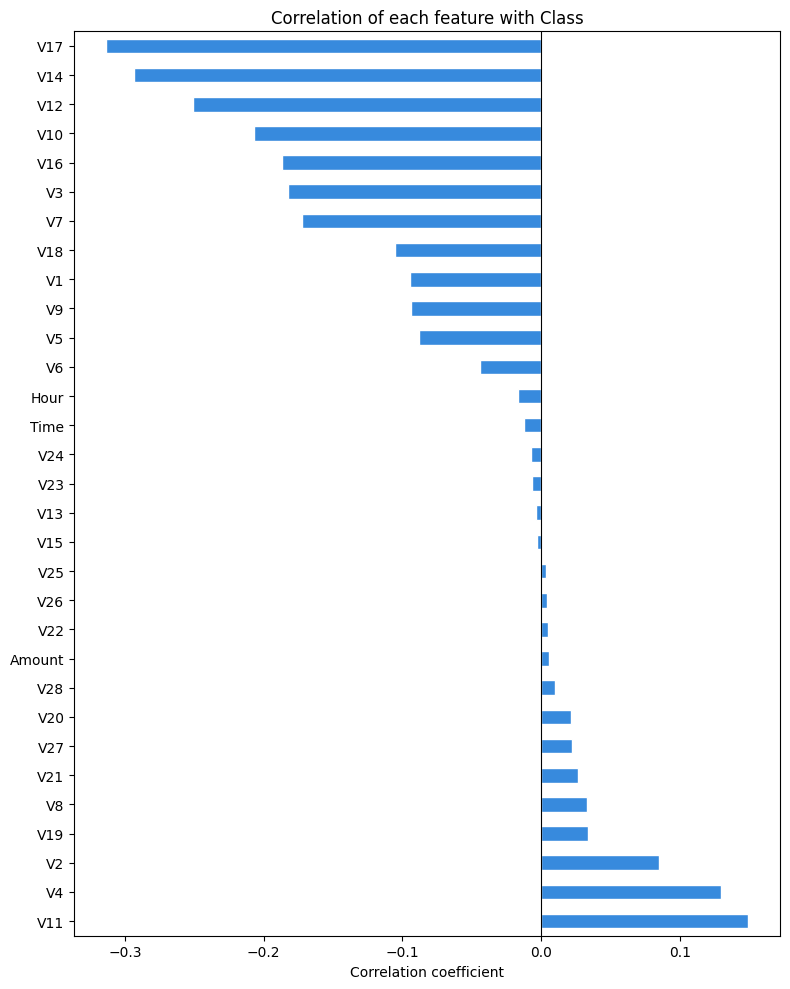

In [180]:
correlations = df_clean.corr(numeric_only=True)['Class'].sort_values(ascending=False)

print("=== Class correlations (sorted) ===")
print(correlations)

plt.figure(figsize=(8, 10))
correlations.drop('Class').plot(kind='barh', color='#378ADD', edgecolor='white')
plt.title('Correlation of each feature with Class')
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/correlation_with_class.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.3 - Heatmap of  global correlation


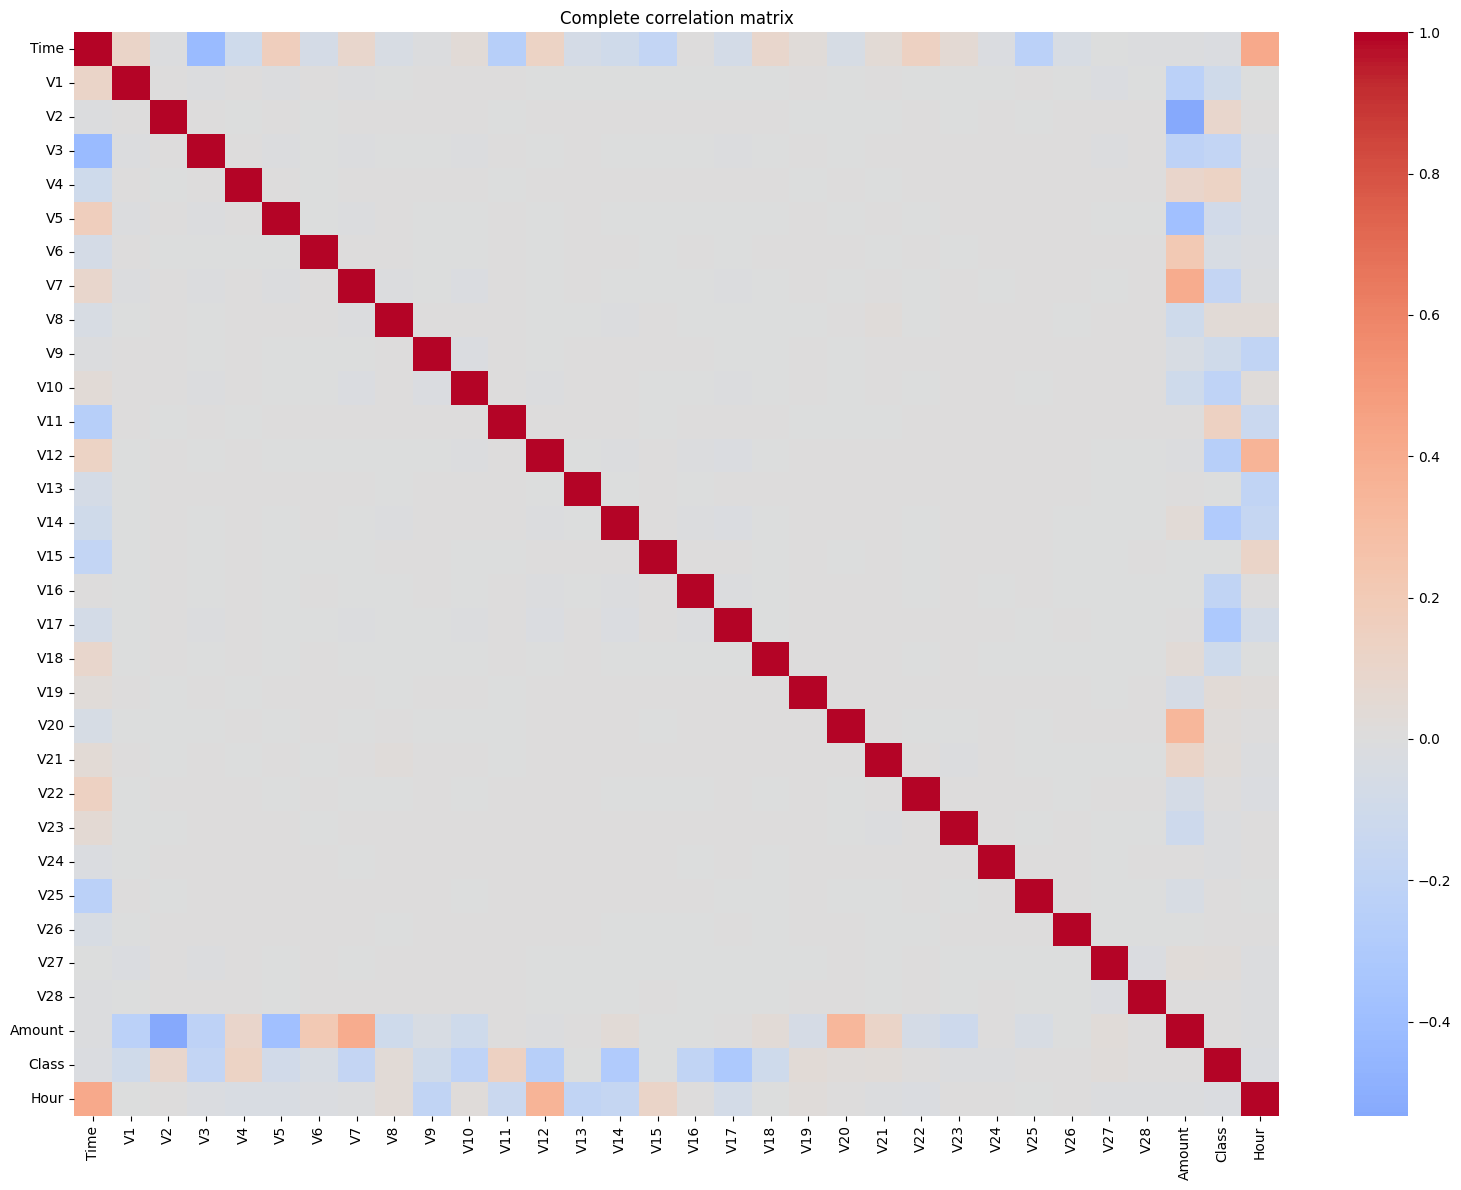

In [181]:
plt.figure(figsize=(16, 12))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm', center=0, annot=False)
plt.title('Complete correlation matrix')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.4 - Focus on the variables most correlated with fraud


Top 5 most correlated features (absolute value) : ['V17', 'V14', 'V12', 'V10', 'V16']


/tmp/ipykernel_4475/1259025908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_4475/1259025908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_4475/1259025908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_4475/1259025908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
/tmp/ipykernel_4475/1259025908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot

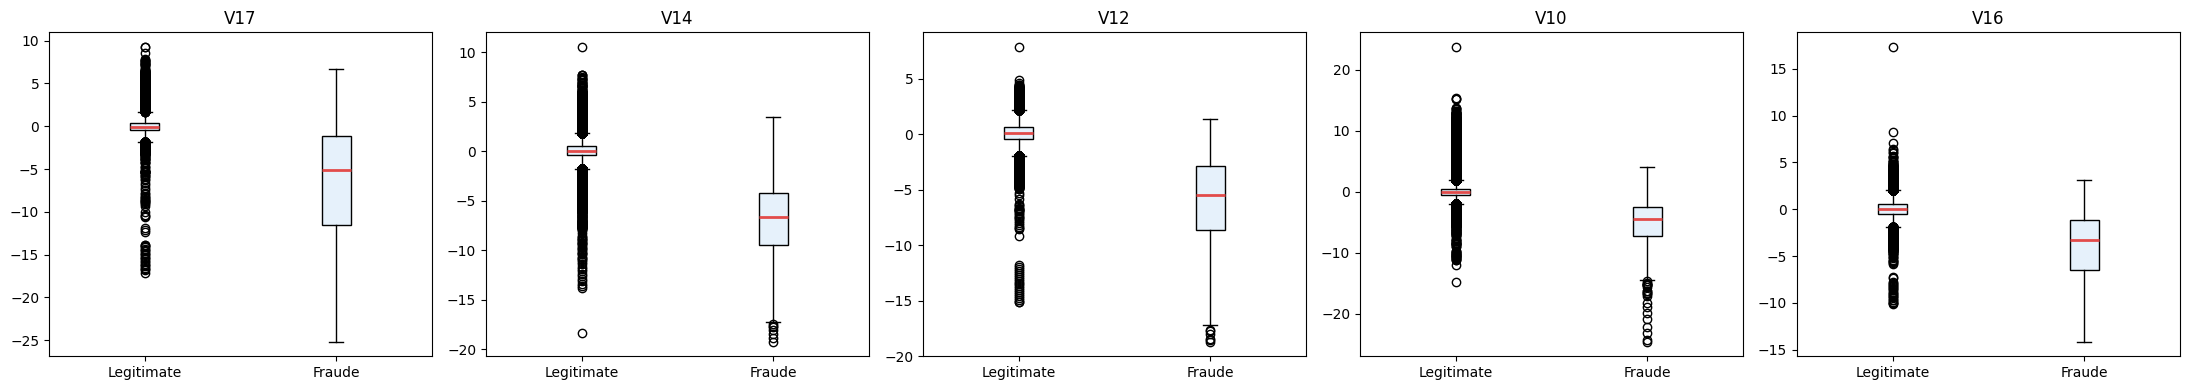

In [182]:
top_features = correlations.drop('Class').abs().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 most correlated features (absolute value) :", top_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, feature in enumerate(top_features):
    axes[i].boxplot(
        [df_clean[df_clean['Class'] == 0][feature], df_clean[df_clean['Class'] == 1][feature]],
        labels=['Legitimate', 'Fraude'],
        patch_artist=True,
        boxprops=dict(facecolor='#E6F1FB'),
        medianprops=dict(color='#E24B4A', linewidth=2)
    )
    axes[i].set_title(feature)

plt.tight_layout()
plt.savefig('figures/top_features_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.5 - Distribution of transactions by hour of the day

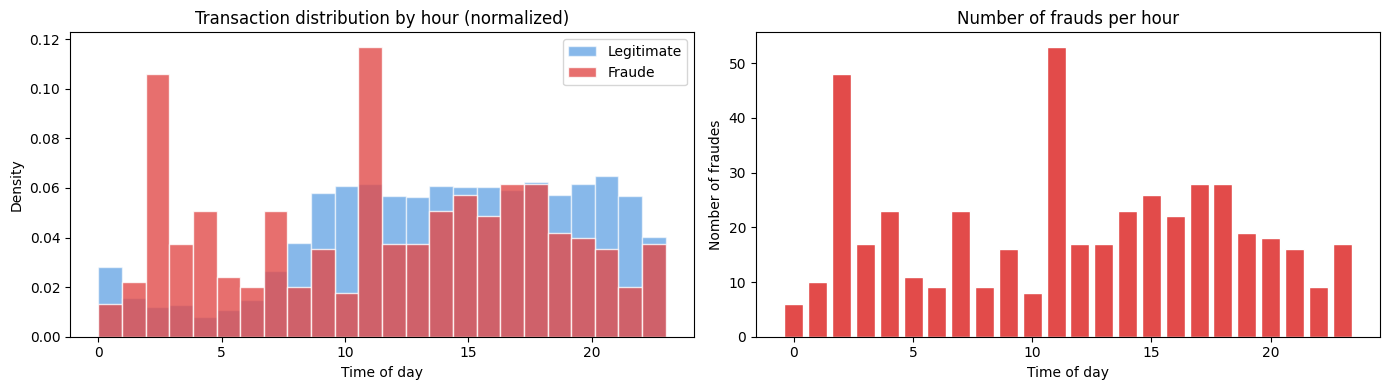

In [183]:
df_clean['Hour'] = (df_clean['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean[df_clean['Class'] == 0]['Hour'], bins=24, alpha=0.6,
             color='#378ADD', label='Legitimate', density=True, edgecolor='white')
axes[0].hist(df_clean[df_clean['Class'] == 1]['Hour'], bins=24, alpha=0.8,
             color='#E24B4A', label='Fraude', density=True, edgecolor='white')
axes[0].set_title('Transaction distribution by hour (normalized)')
axes[0].set_xlabel('Time of day')
axes[0].set_ylabel('Density')
axes[0].legend()

fraud_by_hour = df_clean[df_clean['Class'] == 1].groupby('Hour').size()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#E24B4A', edgecolor='white')
axes[1].set_title('Number of frauds per hour')
axes[1].set_xlabel('Time of day')
axes[1].set_ylabel('Nomber of fraudes')

plt.tight_layout()
plt.savefig('figures/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.1 - Handling class imbalance (SMOTE)

In [184]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

print("=== Before SMOTE ===")
print(y_train.value_counts())
print(f"Fraud percentage: {y_train.mean()*100:.3f}%")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\n=== After SMOTE ===")
print(y_train_balanced.value_counts())
print(f"Fraud percentage: {y_train_balanced.mean()*100:.3f}%")

=== Before SMOTE ===
Class
0    226602
1       378
Name: count, dtype: int64
Fraud percentage: 0.167%

=== After SMOTE ===
Class
0    226602
1    226602
Name: count, dtype: int64
Fraud percentage: 50.000%


# 4.2 - Visualization before/after SMOTE

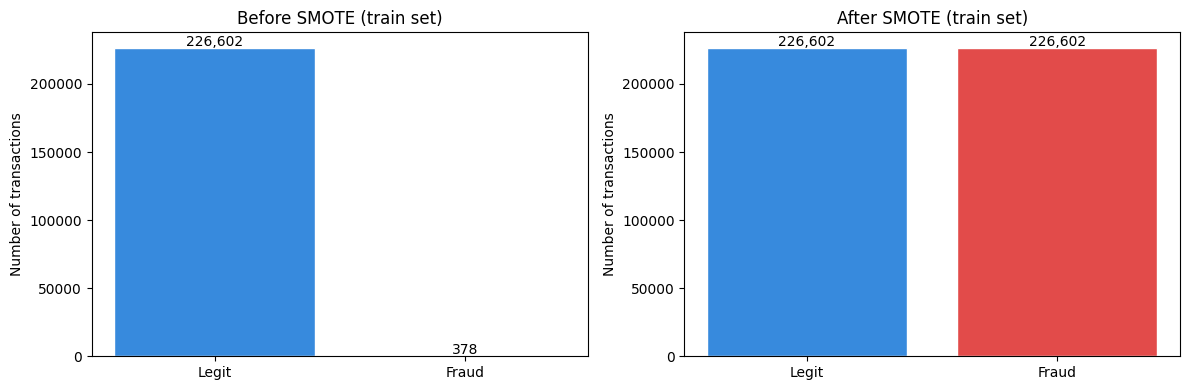

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = y_train.value_counts().sort_index()
after = y_train_balanced.value_counts().sort_index()

axes[0].bar(['Legit', 'Fraud'], before.values, color=['#378ADD', '#E24B4A'], edgecolor='white')
axes[0].set_title('Before SMOTE (train set)')
axes[0].set_ylabel('Number of transactions')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].bar(['Legit', 'Fraud'], after.values, color=['#378ADD', '#E24B4A'], edgecolor='white')
axes[1].set_title('After SMOTE (train set)')
axes[1].set_ylabel('Number of transactions')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig('figures/smote_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.3 - Export data ready for modeling

In [186]:
X_train.to_csv('data/X_train.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print("=== Files exported to data/ ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

=== Files exported to data/ ===
X_train: (226980, 31)
y_train: (226980,)
X_test: (56746, 31)
y_test: (56746,)


# 5.1 - Machine Learning Model Training
- **Logistic Regression** : simple linear model, serves as interpretable baseline
- **Random Forest** : set of decision trees, capture non-linear relationships
- **XGBoost** : sequential boosting, usually the most efficient on unbalanced tabular data

The basic hyperparameters are used (`random_state=42` for reproducibility); they can then be adjusted if necessary (section 7 of the report).

In [187]:
!pip install -q xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

print("Initialized models :", list(models.keys()))

Initialized models : ['Logistic Regression', 'Random Forest', 'XGBoost']


# 5.2 - Training on the balanced train set (SMOTE)

In [194]:
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_balanced, y_train_balanced)
    duration = time.time() - start
    trained_models[name] = model
    print(f"{name} trained in  {duration:.1f}s")

Logistic Regression trained in  24.0s
Random Forest trained in  486.8s
XGBoost trained in  10.8s


# 5.3 - Predictions on the test set (real, unbalanced data)

In [195]:
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

print("Predictions calculated for :", list(predictions.keys()))

Predictions calculated for : ['Logistic Regression', 'Random Forest', 'XGBoost']


# 6. Evaluation Metrics and Results

# 6.1 - Why not accuracy alone?

With 0.17% fraud, a model that still predicts "legitimate" would have ~99.8% accuracy while being completely useless. So we use:
- **Precision** : among the transactions predicted as fraud, how many are really (avoid false positives that block innocent customers)
- **Recall** : among the real frauds, how many are detected (avoid letting fraud go through)
- **F1-score** : balance between the two
- **AUC-ROC** : ability of the model to distinguish between the two classes, regardless of the decision threshold

In [196]:
from sklearn.metrics import classification_report, roc_auc_score

for name in trained_models:
    print(f"\n{'='*50}")
    print(f"=== {name} ===")
    print('='*50)
    y_pred = predictions[name]["y_pred"]
    y_proba = predictions[name]["y_proba"]
    print(classification_report(y_test, y_pred, target_names=['legitimate', 'Fraude'], digits=4))
    print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

  legitimate     0.9998    0.9737    0.9866     56651
      Fraude     0.0528    0.8737    0.0996        95

    accuracy                         0.9736     56746
   macro avg     0.5263    0.9237    0.5431     56746
weighted avg     0.9982    0.9736    0.9851     56746

AUC-ROC : 0.9658

=== Random Forest ===
              precision    recall  f1-score   support

  legitimate     0.9996    0.9999    0.9997     56651
      Fraude     0.9221    0.7474    0.8256        95

    accuracy                         0.9995     56746
   macro avg     0.9608    0.8736    0.9127     56746
weighted avg     0.9994    0.9995    0.9994     56746

AUC-ROC : 0.9552

=== XGBoost ===
              precision    recall  f1-score   support

  legitimate     0.9997    0.9996    0.9996     56651
      Fraude     0.7835    0.8000    0.7917        95

    accuracy                         0.9993     56746
   macro avg     0.8916  

# 6.2 - Confusion matrix

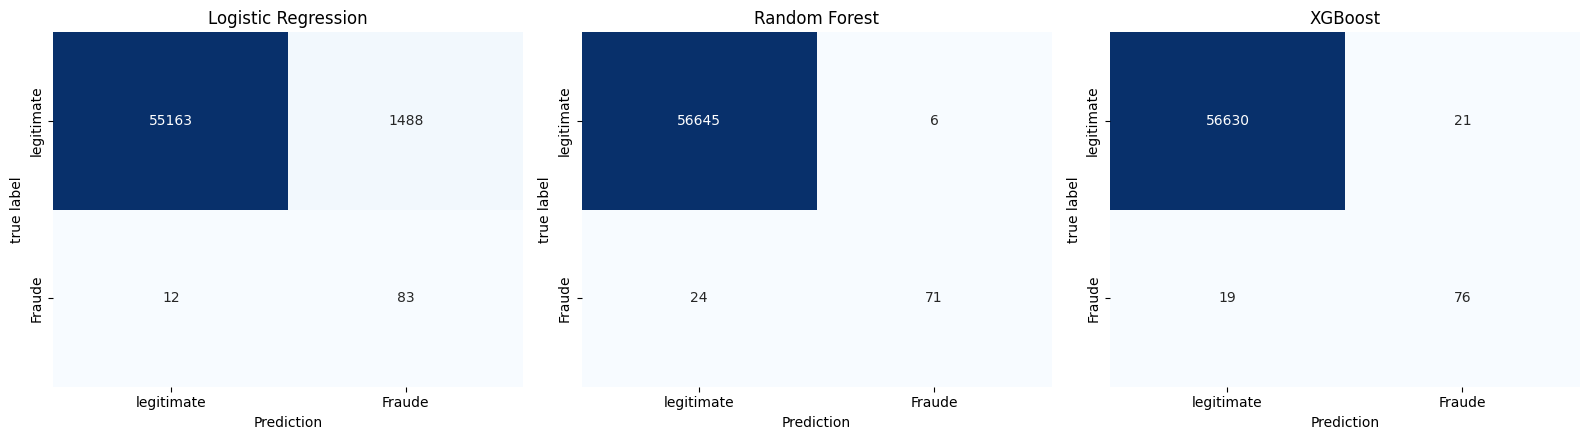

In [197]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['legitimate', 'Fraude'], yticklabels=['legitimate', 'Fraude'])
    ax.set_title(name)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('true label')

plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# 6.3 - Compared ROC curves

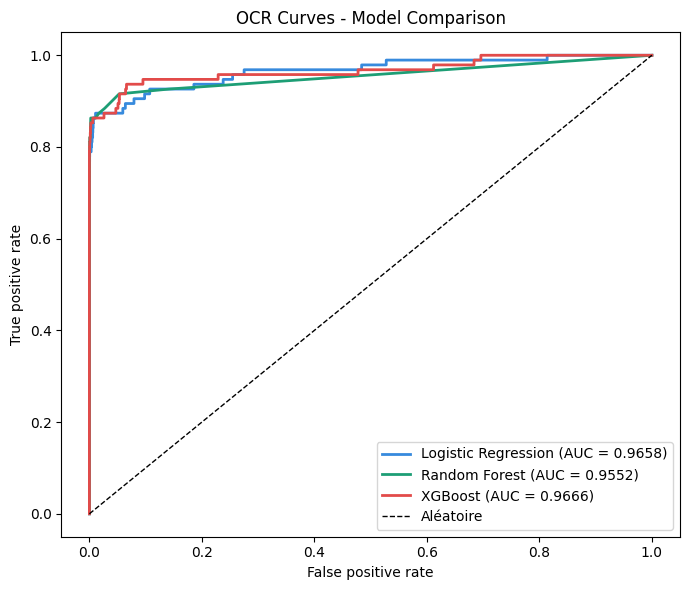

In [198]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

colors = {'Logistic Regression': '#378ADD', 'Random Forest': '#1D9E75', 'XGBoost': '#E24B4A'}

for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]["y_proba"])
    auc = roc_auc_score(y_test, predictions[name]["y_proba"])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colors.get(name), linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('OCR Curves - Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 6.4 - Summary table of metrics

In [199]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for name in trained_models:
    y_pred = predictions[name]["y_pred"]
    y_proba = predictions[name]["y_proba"]
    summary.append({
        "Modele": name,
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4)
    })

summary_df = pd.DataFrame(summary)
print("=== Summary Table ===")
print(summary_df.to_string(index=False))

summary_df.to_csv('data/model_comparison.csv', index=False)

=== Summary Table ===
             Modele  Precision  Recall  F1-score  AUC-ROC
Logistic Regression     0.0528  0.8737    0.0996   0.9658
      Random Forest     0.9221  0.7474    0.8256   0.9552
            XGBoost     0.7835  0.8000    0.7917   0.9666
